In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinFoldingResult
from vqe import VQEC, VQECOpt
from qiskit.circuit.library import RealAmplitudes, EfficientSU2, TwoLocal
from qiskit.primitives import Sampler, Estimator
# from qiskit_aer.primitives import Estimator, Sampler
from qiskit_aer import AerSimulator
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient, LinCombEstimatorGradient, LinCombQGT, SPSAEstimatorGradient, FiniteDiffEstimatorGradient
import numpy as np
import matplotlib.pyplot as plt
from qufold.execution_utils.measurements import _evaluate_sparsepauli
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit

In [3]:
from vqec_optimization_hkn import VQECOpt_hkn 

## VQEC workflow

In [4]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    # penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem

In [5]:
def classify_amino_acids(sequence):
    hydrophobic = set('GAVLIPFMW')
    return ''.join('H' if amino in hydrophobic else 'P' for amino in sequence)

In [50]:
main_seq_4 = "LFLF" # 6MVZ ("LFLF")YYDPETGTWY
protein_folding_problem = build_pf(classify_amino_acids(main_seq_4), 'hp_matrix')
qubit_op = protein_folding_problem.qubit_op()
print(f"Number of qubits: {qubit_op.num_qubits}")
print(f"Number of terms: {len(qubit_op)}")

[[ 0. -1. -1. -1.]
 [ 0.  0. -1. -1.]
 [ 0.  0.  0. -1.]
 [ 0.  0.  0.  0.]]
Number of qubits: 9
Number of terms: 107


In [37]:
print(qubit_op)

SparsePauliOp(['IIIIIIIII', 'IIIZZIIII', 'IIIZIZZII', 'IIIIZZZII', 'IIIIIIZZI', 'IIIZZIZZI', 'IIIZIZIZI', 'IIIIZZIZI', 'IIIIIZIIZ', 'IIIZZZIIZ', 'IIIZIIZIZ', 'IIIIZIZIZ', 'IIIIIZZZZ', 'IIIZZZZZZ', 'IIIZIIIZZ', 'IIIIZIIZZ', 'IIIIIZZII', 'IIIZZZZII', 'IIIIIIIZI', 'IIIIIIIZZ', 'IIZIIIIII', 'IIZIIIIZI', 'IIZIIIIZZ', 'IIIIIZIII', 'IIIZIZIII', 'IIIIZZIII', 'IIIZZZIII', 'IIIIIIZII', 'IIIZIIZII', 'IIIIZIZII', 'IIIZZIZII', 'IIIIIZIZI', 'IIIZZZIZI', 'IIIZIIZZI', 'IIIZIIIII', 'IIIIZIIII', 'IIIIIZIZZ', 'IIIZZZIZZ', 'IIIIIIZZZ', 'IIIZZIZZZ', 'IIIZIZZZZ', 'IIIIZZZZZ', 'IIIIZZIIZ', 'IZIIIIIII', 'IZIIIIIZI', 'IZIIIZIII', 'IZIZIZIII', 'IZIIZZIII', 'IZIZZZIII', 'IZIIIIZII', 'IZIZIIZII', 'IZIIZIZII', 'IZIZZIZII', 'IZIIIZIZI', 'IZIZIZIZI', 'IZIIZZIZI', 'IZIZZZIZI', 'IZIIIIZZI', 'IZIZIIZZI', 'IZIZZIZZI', 'IZIZIIIII', 'IZIIZIIII', 'IZIZZIIII', 'IZIIIZZII', 'IZIZIZZII', 'IZIIZZZII', 'IZIZZZZII', 'IZIIIIIZZ', 'IZIZIIIZZ', 'IZIIZIIZZ', 'IZIIIZIZZ', 'IZIZZZIZZ', 'IZIIIIZZZ', 'IZIZZIZZZ', 'IZIZIZZZZ', 'IZIIZZZZZ

In [38]:
bead_pairs, olap_constr_ops = protein_folding_problem.olap_constr_ops()
print(f"Number of overlap constraints: {len(olap_constr_ops)}")
print(f"Number of qubits: {olap_constr_ops[0].num_qubits}")

Number of overlap constraints: 1
Number of qubits: 9


In [41]:
# ansatz_ra = RealAmplitudes(qubit_op.num_qubits, skip_final_rotation_layer=False)

ansatz_su2 = EfficientSU2(qubit_op.num_qubits, reps=1, skip_final_rotation_layer=False)

In [42]:
estimator = Estimator()
# estimator = Estimator(backend_options={'method': 'matrix_product_state'})
gradient= LinCombEstimatorGradient(estimator=estimator)

C:\Users\8J6010897\AppData\Local\Temp\ipykernel_73060\1587716434.py:1: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()


100%|██████████| 200/200 [01:24<00:00,  2.38it/s]


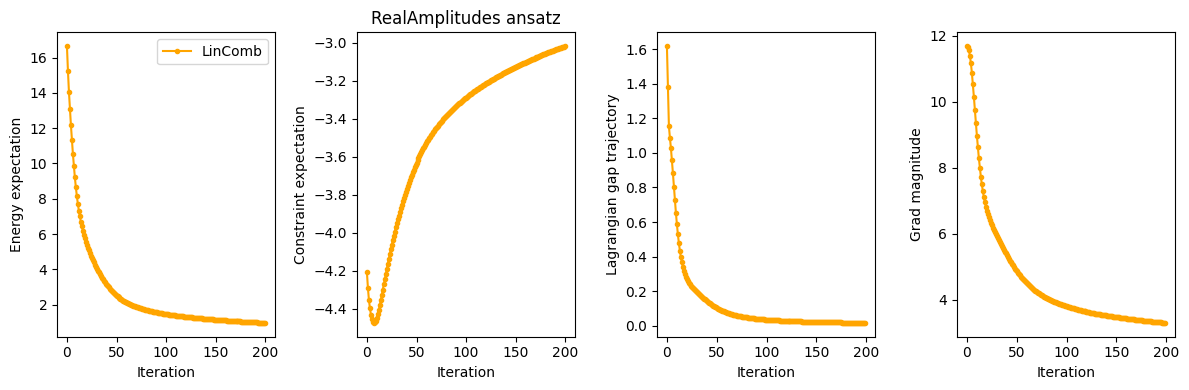

In [51]:
vqec = VQECOpt_hkn(primal_perturb_step=0.01, dual_perturb_step=0.089, qubit_op=qubit_op, constr_ops=olap_constr_ops, ansatz=ansatz_su2, estimator=estimator, gradient=gradient, max_iter=200)
vqec_result = vqec.optimize_primal_dual()

# Plot the results
fig, ax = plt.subplots(1, 4, figsize=(12, 4))
ax[0].plot(vqec_result.energies, label="LinComb", marker=".", color ='orange')
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Energy expectation")

ax[1].plot(vqec_result.constraints[:, 0], label="Overlap", marker=".", color ='orange')
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Constraint expectation")

ax[2].plot(vqec_result.lagrangian_gap_trajectory, label="Dual", marker=".", color='orange')
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("Lagrangian gap trajectory")

ax[3].plot(vqec_result.gradient_norms, label="Gradient norm", marker=".", color='orange')
ax[3].set_xlabel("Iteration")
ax[3].set_ylabel("Grad magnitude")

ax[0].legend()
ax[1].set_title('RealAmplitudes ansatz')

plt.tight_layout()
plt.show()

In [49]:
full_circ = vqec_result.ansatz.copy()
full_circ.measure_all()
sampler = Sampler(options={"shots": 10000})
# sampler = Sampler(run_options={"shots": 10000})
sampler_result = sampler.run(circuits=[full_circ], parameter_values=vqec_result.optimal_primal_vars).result()
quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()

# Sort the binary strings by their probabilities
sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))
# Compute the energies of all samples
from qufold.execution_utils.measurements import _evaluate_sparsepauli
bitstring_energies = {}
for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
    if i >= 5:
        break
    energy = _evaluate_sparsepauli(sample, qubit_op)
    bitstring_energies[sample] = energy
    print(f"Sample {i}: {sample} with probability {prob} and energy {energy}")

Sample 0: 000110110 with probability 0.4058 and energy 0.0
Sample 1: 000110101 with probability 0.3358 and energy -1.7763568394002505e-15
Sample 2: 000100110 with probability 0.0822 and energy 1.7763568394002505e-15
Sample 3: 000100101 with probability 0.0655 and energy -3.552713678800501e-15
Sample 4: 000110111 with probability 0.0508 and energy 5.329070518200751e-15


C:\Users\8J6010897\AppData\Local\Temp\ipykernel_73060\2213236805.py:3: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": 10000})


In [22]:
# Optimal solution for LFLF
print(_evaluate_sparsepauli("111111110", qubit_op))

print(_evaluate_sparsepauli("001001110", qubit_op))

-3.0
-1.0


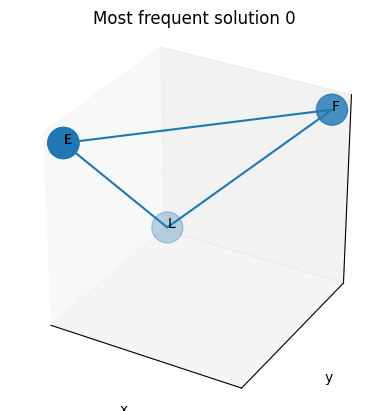

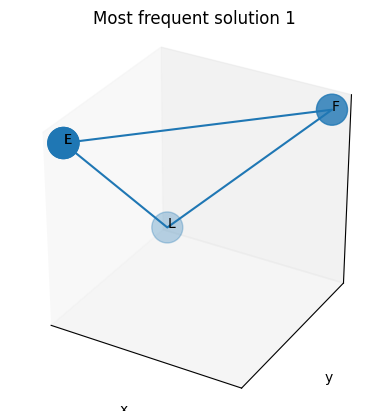

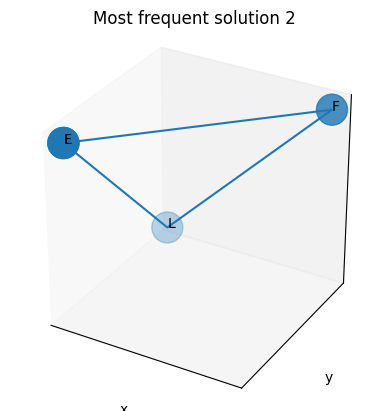

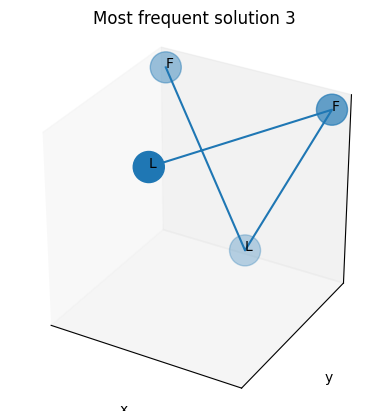

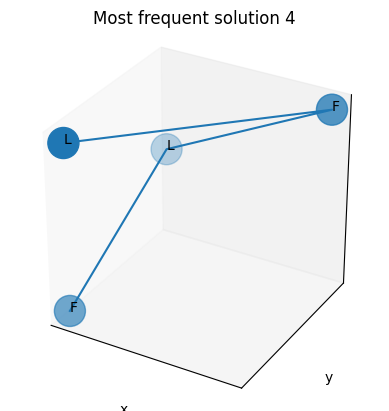

In [24]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    fig = pf_result.get_figure(title=f"Most frequent solution {i}")
    plt.show()

In [11]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    print(f"Turn sequence: {pf_result.turn_sequence}")
    xyz_coords = pf_result.protein_shape_file_gen.get_xyz_data()
    print(xyz_coords)
    distances = []
    xyz_coords = xyz_coords[:, 1::]
    # Convert the coordinates to float
    xyz_coords = xyz_coords.astype(float)
    for i in range(len(xyz_coords)):
        for j in range(i + 2, len(xyz_coords)):
            distance = (np.linalg.norm(xyz_coords[i] - xyz_coords[j]) / 3.8 * np.sqrt(2)) ** 2
            distances.append(distance)
    print(distances)

Turn sequence: [0, 9, 5]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '0.0' '0.0' '-5.37401153701776']]
[1.9999999999999996, 4.0, 5.999999999999999]
Turn sequence: [0, 9, 11]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '-2.68700576850888' '2.68700576850888' '0.0']]
[1.9999999999999996, 1.9999999999999996, 4.0]
Turn sequence: [0, 9, 11]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '-2.68700576850888' '2.68700576850888' '0.0']]
[1.9999999999999996, 1.9999999999999996, 4.0]
Turn sequence: [0, 9, 5]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '0.0' '0.0' '-5.37401153701776']]
[1.9999999999999996, 4.0, 5.999999999999999]
Turn sequence: [0,

In [12]:
test_op = SparsePauliOp.from_list([("ZII", 1)])
print(test_op)
print(_evaluate_sparsepauli("000", test_op))
print(_evaluate_sparsepauli("001", test_op))
print(_evaluate_sparsepauli("100", test_op))

SparsePauliOp(['ZII'],
              coeffs=[1.+0.j])
1.0
1.0
-1.0


## Checking qubit_op

In [13]:
from fcc.fcc_qubit_op_builder import QubitOpBuilder
from fcc.fcc_distance_map import DistanceMap
from fcc.utils import remove_unused_qubits

In [14]:
main_seq_4

'LFLF'

In [15]:
peptide = Peptide(main_seq_4)
mj_interaction = MiyazawaJerniganInteraction("mj_matrix")
pair_energies = mj_interaction.calculate_energy_matrix(main_seq_4)
penalty_params = PenaltyParameters(50, 50)

qubit_op_builder = QubitOpBuilder(peptide, pair_energies, penalty_params)

In [16]:
contact_op = qubit_op_builder._create_h_contact()
print(contact_op.num_qubits)

# "001001110" -> full bitstring: "001001100100000"
print(_evaluate_sparsepauli("001001100100000", contact_op))

full_qubit_op = qubit_op_builder.build_qubit_op()
print(full_qubit_op.num_qubits)
print(_evaluate_sparsepauli("001001100100000", full_qubit_op))

15
-7.369999999999994
15
-7.36999999999999


In [17]:
reduced_qubit_op, unused_qubits = remove_unused_qubits(full_qubit_op)
print(unused_qubits)
print(reduced_qubit_op.num_qubits)
print(_evaluate_sparsepauli("001001110", reduced_qubit_op))

[0, 1, 2, 3, 6, 7]
9
-7.36999999999999


In [18]:
DM = DistanceMap(peptide)
distance_map = DM.distance_map
distance_map

defaultdict(dict,
            {'0': {'1': SparsePauliOp(['IIIIIIIIIIII'],
                            coeffs=[2.+0.j]),
              '2': SparsePauliOp(['IIIIIIIIIIII', 'IIIIIIZIIIII', 'IIIIIIZZIIII'],
                            coeffs=[5.+0.j, 2.+0.j, 1.+0.j]),
              '3': SparsePauliOp(['IIIIIIIIIIII', 'IIIIIIZIIIII', 'IIZIIIIIIIII', 'ZIZIIIIIIIII', 'IZZIIIIIIIII', 'ZZZIIIIIIIII', 'IIIZIIIIIIII', 'ZIIZIIIIIIII', 'IZIZIIIIIIII', 'ZZIZIIIIIIII', 'IIZIIIZIIIII', 'ZIZIIIZIIIII', 'IZZIIIZIIIII', 'ZZZIIIZIIIII', 'IIIZIIZIIIII', 'ZIIZIIZIIIII', 'ZZIZIIZIIIII', 'ZIIIIIIIIIII', 'IZIIIIIIIIII', 'ZZIIIIIIIIII', 'IIZZIIIIIIII', 'ZIZZIIIIIIII', 'IZZZIIIIIIII', 'ZZZZIIIIIIII', 'IIIIIIZZIIII', 'ZIIIIIZZIIII', 'IZIIIIZZIIII', 'IIZIIIZZIIII', 'ZZZIIIZZIIII', 'IIIZIIZZIIII', 'ZZIZIIZZIIII', 'ZIZZIIZZIIII', 'IZZZIIZZIIII', 'IZZIIIIZIIII', 'IZIZIIIZIIII'],
                            coeffs=[ 6.5 +0.j,  2.  +0.j,  1.25+0.j,  0.5 +0.j,  0.5 +0.j, -0.25+0.j,
               -1.25+0.j,  0.5 +0.j,  

In [19]:
print(_evaluate_sparsepauli("001100100000", distance_map['0']['2']))
print(_evaluate_sparsepauli("001100100000", distance_map['0']['3']))
print(_evaluate_sparsepauli("001100100000", distance_map['1']['3']))

2.0
6.0
6.0


In [20]:
bead_idx = 3
print(_evaluate_sparsepauli("001100100000", DM._compute_x_coordinate(bead_idx)))
print(_evaluate_sparsepauli("001100100000", DM._compute_y_coordinate(bead_idx)))
print(_evaluate_sparsepauli("001100100000", DM._compute_z_coordinate(bead_idx)))

-1.0
2.0
-1.0


## Demo of a potential "issue"

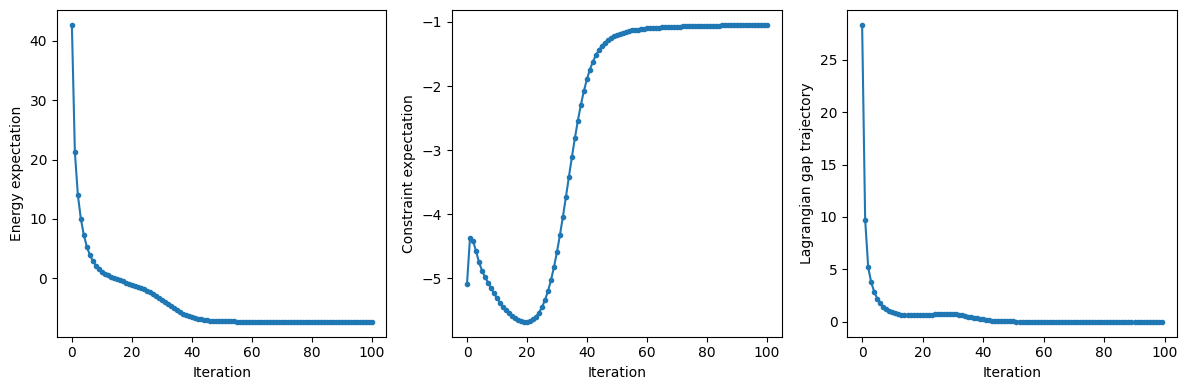

In [21]:
# Plot the results
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].plot(vqec_result.energies, label="Energy", marker=".")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Energy expectation")

ax[1].plot(vqec_result.constraints[:, 0], label="Overlap", marker=".")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Constraint expectation")

ax[2].plot(vqec_result.lagrangian_gap_trajectory, label="Dual", marker=".")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("Lagrangian gap trajectory")



plt.tight_layout()
plt.show()

In [22]:
full_circ = vqec_result.ansatz.copy()
full_circ.measure_all()
sampler = Sampler(options={"shots": 10000})
# sampler = Sampler(run_options={"shots": 10000})
sampler_result = sampler.run(circuits=[full_circ], parameter_values=vqec_result.optimal_primal_vars).result()
quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()

# Sort the binary strings by their probabilities
sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))
# Compute the energies of all samples
from qufold.execution_utils.measurements import _evaluate_sparsepauli
bitstring_energies = {}
for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
    if i >= 5:
        break
    energy = _evaluate_sparsepauli(sample, qubit_op)
    bitstring_energies[sample] = energy
    print(f"Sample {i}: {sample} with probability {prob} and energy {energy}")

Sample 0: 001101010 with probability 0.515 and energy -7.3700000000000045
Sample 1: 001111010 with probability 0.469 and energy -7.369999999999996
Sample 2: 011101010 with probability 0.0072 and energy -0.09000000000000075
Sample 3: 011111010 with probability 0.0062 and energy -14.650000000000006
Sample 4: 000010101 with probability 0.0012 and energy -8.881784197001252e-15


C:\Users\8J6010897\AppData\Local\Temp\ipykernel_44376\2213236805.py:3: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": 10000})


Note that the second solution above seems to be a valid solution, but clearly, the interaction qubits are not consistent with the configuration qubits. For a given set of configuration qubits, the interaction qubits can be determined completely. 

How should we eliminate such inconsistent bitstrings?
- By postprocessing.
- Better yet, by eliminating them at the Hamiltonian level, which also reduces the search space. But how?

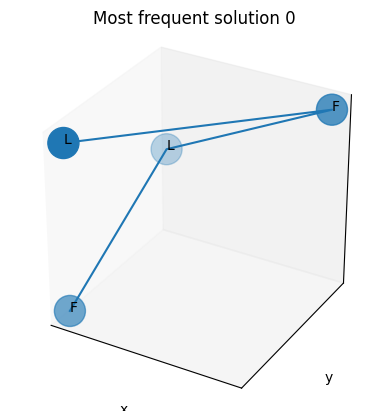

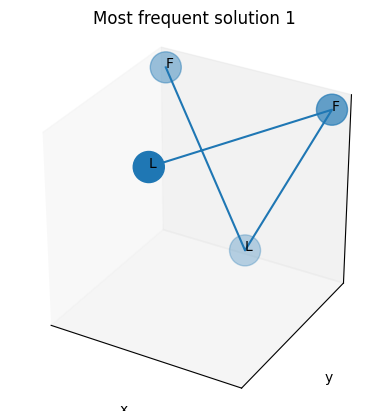

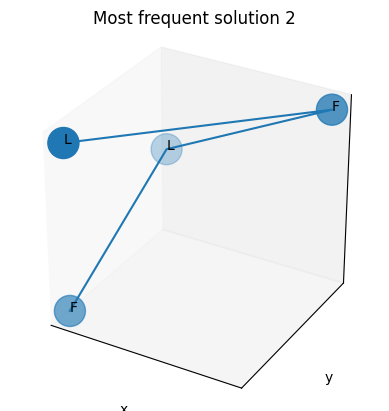

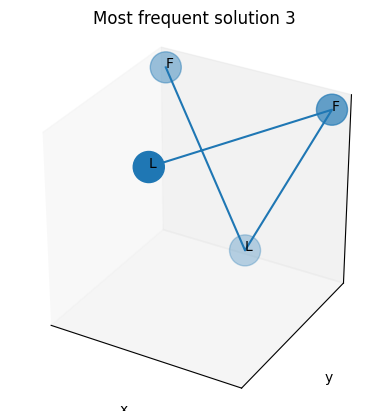

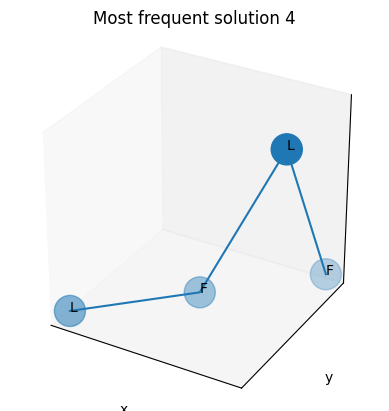

In [23]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    fig = pf_result.get_figure(title=f"Most frequent solution {i}")
    plt.show()

In [24]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    print(f"Turn sequence: {pf_result.turn_sequence}")
    xyz_coords = pf_result.protein_shape_file_gen.get_xyz_data()
    print(xyz_coords)
    distances = []
    xyz_coords = xyz_coords[:, 1::]
    # Convert the coordinates to float
    xyz_coords = xyz_coords.astype(float)
    for i in range(len(xyz_coords)):
        for j in range(i + 2, len(xyz_coords)):
            distance = (np.linalg.norm(xyz_coords[i] - xyz_coords[j]) / 3.8 * np.sqrt(2)) ** 2
            distances.append(distance)
    print(distances)

Turn sequence: [0, 9, 5]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '0.0' '0.0' '-5.37401153701776']]
[1.9999999999999996, 4.0, 5.999999999999999]
Turn sequence: [0, 9, 11]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '-2.68700576850888' '2.68700576850888' '0.0']]
[1.9999999999999996, 1.9999999999999996, 4.0]
Turn sequence: [0, 9, 5]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '0.0' '0.0' '-5.37401153701776']]
[1.9999999999999996, 4.0, 5.999999999999999]
Turn sequence: [0, 9, 11]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '-2.68700576850888' '2.68700576850888' '0.0']]
[1.9999999999999996, 1.9999999999999996, 4.0]
Turn sequence: [0,